Week 8 Capstone: Notebook 2 - EDA Analysis Pipeline
Cell-by-Cell Code Guide

In [3]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Load clean data
sales_clean = pd.read_csv(r"C:\Users\ravis\Downloads\sales_data.csv")
churn_clean = pd.read_csv(r"C:\Users\ravis\Downloads\customer_churn.csv")

print("✅ Data loaded")


✅ Data loaded


In [5]:
import os

# Create outputs folder if it doesn't exist
os.makedirs('outputs', exist_ok=True)

print("✅ outputs folder created")


✅ outputs folder created


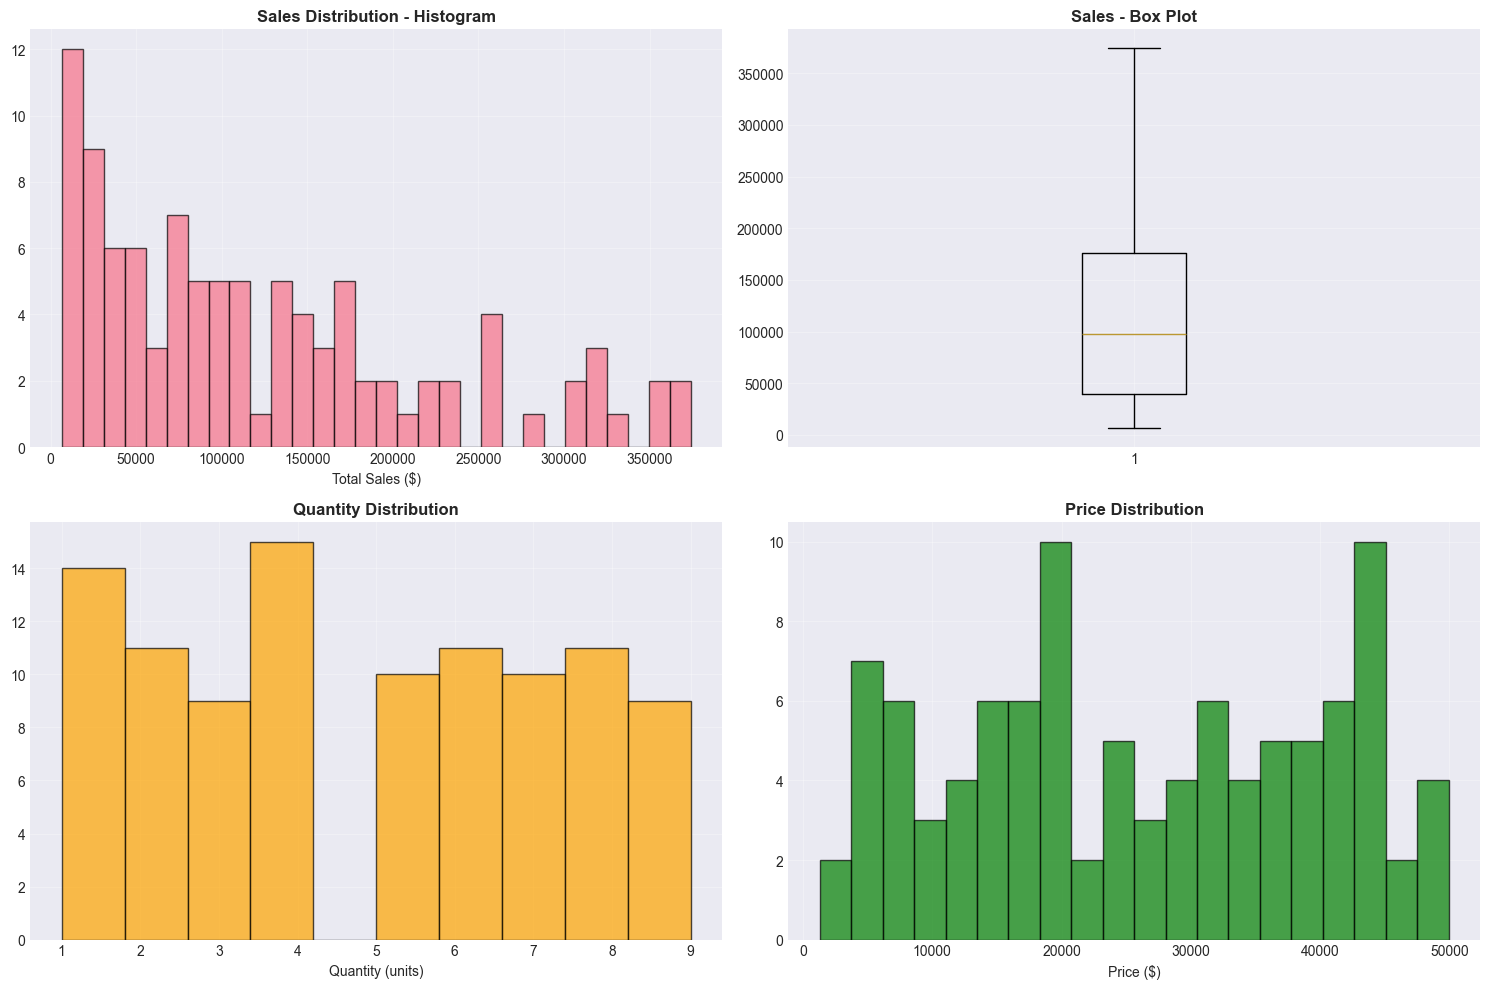

✅ Sales distributions visualized


In [6]:
import os
import matplotlib.pyplot as plt

# Create outputs folder if it doesn't exist
os.makedirs('outputs', exist_ok=True)

# Create visualizations
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Histogram
axes[0, 0].hist(sales_clean['total_sales'], bins=30, edgecolor='black', alpha=0.7)
axes[0, 0].set_title('Sales Distribution - Histogram', fontweight='bold')
axes[0, 0].set_xlabel('Total Sales ($)')
axes[0, 0].grid(True, alpha=0.3)

# Box plot
axes[0, 1].boxplot(sales_clean['total_sales'])
axes[0, 1].set_title('Sales - Box Plot', fontweight='bold')
axes[0, 1].grid(True, alpha=0.3)

# Quantity distribution
axes[1, 0].hist(sales_clean['quantity'], bins=10, edgecolor='black', alpha=0.7, color='orange')
axes[1, 0].set_title('Quantity Distribution', fontweight='bold')
axes[1, 0].set_xlabel('Quantity (units)')
axes[1, 0].grid(True, alpha=0.3)

# Price distribution
axes[1, 1].hist(sales_clean['price'], bins=20, edgecolor='black', alpha=0.7, color='green')
axes[1, 1].set_title('Price Distribution', fontweight='bold')
axes[1, 1].set_xlabel('Price ($)')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('outputs/02_sales_distributions.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Sales distributions visualized")


Overall Churn Rate: 0.0%

Churn by Contract Type:
                Total  Churned  Rate
contract                            
Month-to-month    170        0   0.0
One year          186        0   0.0
Two year          144        0   0.0


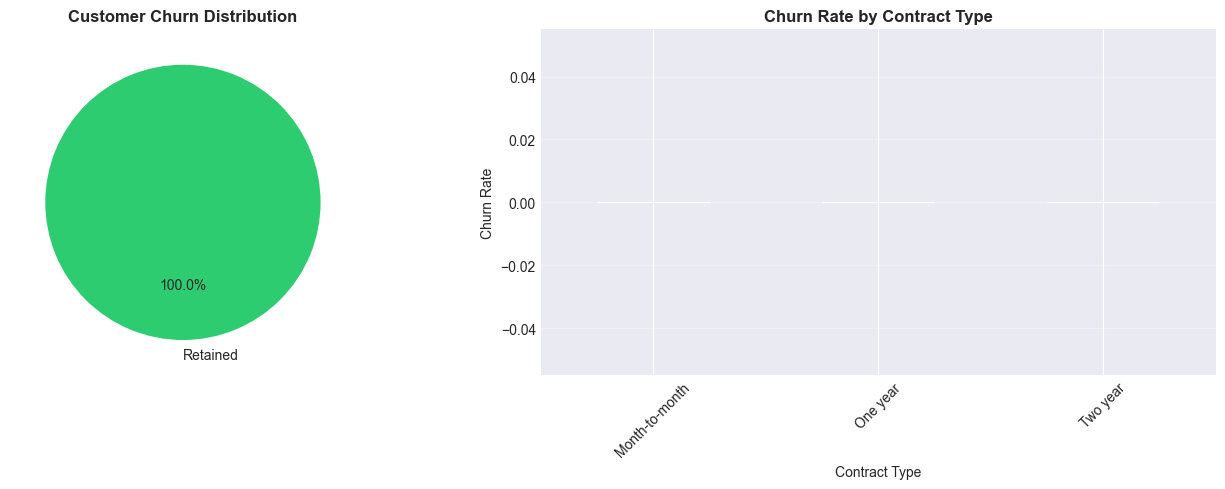

✅ Churn analysis complete


In [13]:
import os
import matplotlib.pyplot as plt

os.makedirs('outputs', exist_ok=True)

# Churn rate
churn_rate = churn_clean['churn_flag'].mean()
print(f"Overall Churn Rate: {churn_rate*100:.1f}%")

# Churn by contract
churn_by_contract = churn_clean.groupby('contract')['churn_flag'].agg(['count', 'sum', 'mean'])
churn_by_contract.columns = ['Total', 'Churned', 'Rate']
print("\nChurn by Contract Type:")
print(churn_by_contract)

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Churn pie chart (FIXED: Sort and map labels correctly)
churn_counts = churn_clean['churn_flag'].value_counts().sort_index()
labels_map = {0: 'Retained', 1: 'Churned'}
labels = [labels_map[i] for i in churn_counts.index]
colors = ['#2ecc71', '#e74c3c']  # Green for retained, red for churned

axes[0].pie(churn_counts.values,
            labels=labels,
            autopct='%1.1f%%',
            startangle=90,
            colors=colors)
axes[0].set_title('Customer Churn Distribution', fontweight='bold')

# Churn by contract
churn_by_contract['Rate'].plot(kind='bar', ax=axes[1], color=['blue', 'orange', 'green'])
axes[1].set_title('Churn Rate by Contract Type', fontweight='bold')
axes[1].set_ylabel('Churn Rate')
axes[1].set_xlabel('Contract Type')
axes[1].grid(True, alpha=0.3, axis='y')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45)

plt.tight_layout()
plt.savefig('outputs/02_churn_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Churn analysis complete")


In [14]:
# Sales correlations
sales_corr = sales_clean[['quantity', 'price', 'total_sales']].corr()
print("📊 SALES CORRELATION MATRIX")
print(sales_corr.round(4))

# Churn correlations
churn_numeric = churn_clean[['tenure', 'monthlycharges', 'churn_flag']].corr()
print("\n📊 CHURN CORRELATION MATRIX")
print(churn_numeric.round(4))


📊 SALES CORRELATION MATRIX
             quantity   price  total_sales
quantity       1.0000  0.0080       0.6881
price          0.0080  1.0000       0.6461
total_sales    0.6881  0.6461       1.0000

📊 CHURN CORRELATION MATRIX
                tenure  monthlycharges  churn_flag
tenure          1.0000         -0.0597         NaN
monthlycharges -0.0597          1.0000         NaN
churn_flag         NaN             NaN         NaN


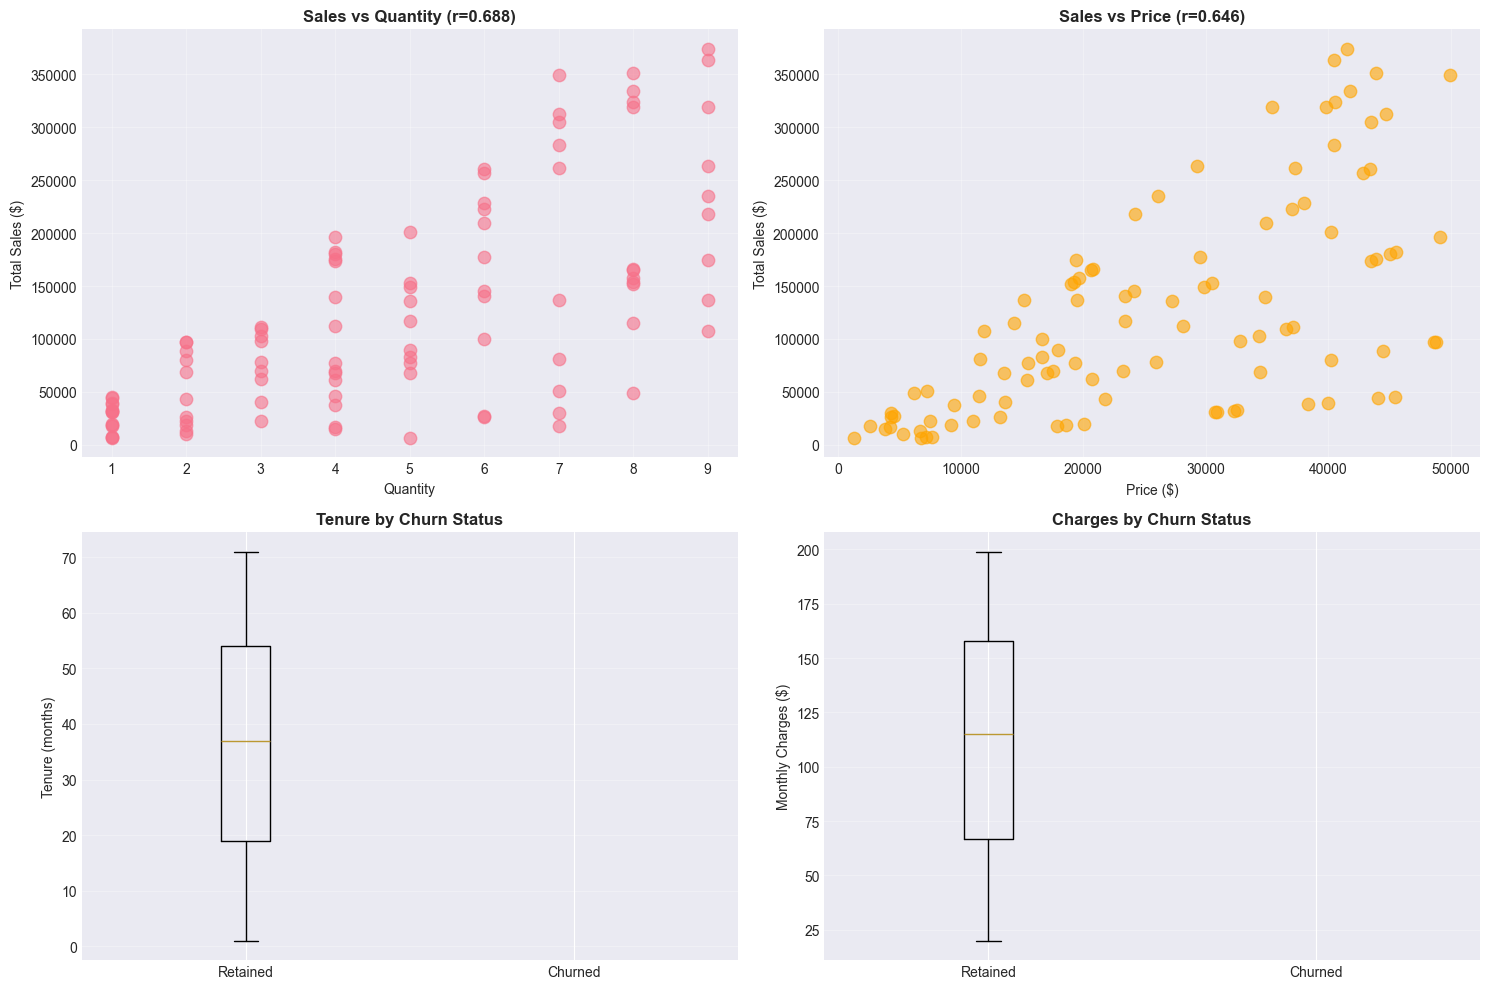

✅ Key relationships visualized


In [15]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Sales vs Quantity
axes[0, 0].scatter(sales_clean['quantity'], sales_clean['total_sales'], alpha=0.6, s=80)
axes[0, 0].set_xlabel('Quantity')
axes[0, 0].set_ylabel('Total Sales ($)')
axes[0, 0].set_title(f'Sales vs Quantity (r={sales_corr.loc["quantity", "total_sales"]:.3f})', fontweight='bold')
axes[0, 0].grid(True, alpha=0.3)

# Sales vs Price
axes[0, 1].scatter(sales_clean['price'], sales_clean['total_sales'], alpha=0.6, s=80, color='orange')
axes[0, 1].set_xlabel('Price ($)')
axes[0, 1].set_ylabel('Total Sales ($)')
axes[0, 1].set_title(f'Sales vs Price (r={sales_corr.loc["price", "total_sales"]:.3f})', fontweight='bold')
axes[0, 1].grid(True, alpha=0.3)

# Tenure by Churn
retained = churn_clean[churn_clean['churn_flag'] == 0]['tenure']
churned = churn_clean[churn_clean['churn_flag'] == 1]['tenure']
axes[1, 0].boxplot([retained, churned], labels=['Retained', 'Churned'])
axes[1, 0].set_ylabel('Tenure (months)')
axes[1, 0].set_title('Tenure by Churn Status', fontweight='bold')
axes[1, 0].grid(True, alpha=0.3, axis='y')

# Monthly Charges by Churn
retained_charges = churn_clean[churn_clean['churn_flag'] == 0]['monthlycharges']
churned_charges = churn_clean[churn_clean['churn_flag'] == 1]['monthlycharges']
axes[1, 1].boxplot([retained_charges, churned_charges], labels=['Retained', 'Churned'])
axes[1, 1].set_ylabel('Monthly Charges ($)')
axes[1, 1].set_title('Charges by Churn Status', fontweight='bold')
axes[1, 1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('outputs/02_key_relationships.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Key relationships visualized")


Shapiro-Wilk Test (Sales): p=0.0000 NOT NORMAL
Shapiro-Wilk Test (Tenure): p=0.0000 NOT NORMAL


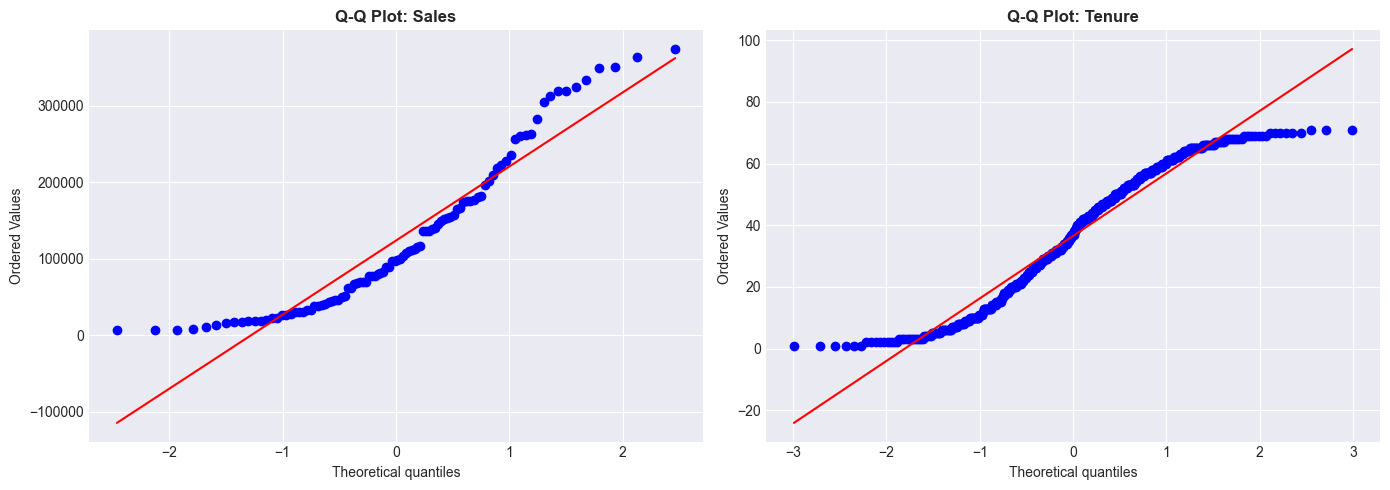

✅ Normality testing complete


In [17]:
import os
import matplotlib.pyplot as plt
from scipy import stats

os.makedirs('outputs', exist_ok=True)

# Shapiro-Wilk test for sales
shapiro_stat, shapiro_p = stats.shapiro(sales_clean['total_sales'])
print(f"Shapiro-Wilk Test (Sales): p={shapiro_p:.4f} {'NORMAL' if shapiro_p > 0.05 else 'NOT NORMAL'}")

# Shapiro-Wilk test for tenure
shapiro_tenure, shapiro_p_tenure = stats.shapiro(churn_clean['tenure'])
print(f"Shapiro-Wilk Test (Tenure): p={shapiro_p_tenure:.4f} {'NORMAL' if shapiro_p_tenure > 0.05 else 'NOT NORMAL'}")

# Q-Q plots (FIXED: use axes[0] and axes[1])
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# First Q-Q plot: Sales
stats.probplot(sales_clean['total_sales'], dist="norm", plot=axes[0])
axes[0].set_title('Q-Q Plot: Sales', fontweight='bold')

# Second Q-Q plot: Tenure
stats.probplot(churn_clean['tenure'], dist="norm", plot=axes[1])
axes[1].set_title('Q-Q Plot: Tenure', fontweight='bold')

plt.tight_layout()
plt.savefig('outputs/02_normality_tests.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Normality testing complete")


In [18]:
# IQR method for outlier detection
def count_outliers(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5*IQR
    upper = Q3 + 1.5*IQR
    outliers = ((df[col] < lower) | (df[col] > upper)).sum()
    return outliers, len(df)

sales_outliers, n_sales = count_outliers(sales_clean, 'total_sales')
print(f"Sales outliers: {sales_outliers}/{n_sales} ({sales_outliers/n_sales*100:.1f}%)")

tenure_outliers, n_tenure = count_outliers(churn_clean, 'tenure')
print(f"Tenure outliers: {tenure_outliers}/{n_tenure} ({tenure_outliers/n_tenure*100:.1f}%)")

print("✅ Outlier detection complete")


Sales outliers: 0/100 (0.0%)
Tenure outliers: 0/500 (0.0%)
✅ Outlier detection complete
